## Load imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nfl_data_py as nfl

## Load in schedules from nfl

In [7]:
seasons = [2021, 2022, 2023, 2024, 2025]
sched = nfl.import_schedules(seasons)
sched = sched[sched["game_type"] == "REG"].copy() # Use only regular season games for now
sched.tail()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
7258,2025_18_ARI_LA,2025,REG,18,2026-01-04,Sunday,16:25,ARI,20,LA,...,NaN,00-0033119,00-0026498,Jacoby Brissett,Matthew Stafford,Jonathan Gannon,Sean McVay,Carl Cheffers,LAX01,SoFi Stadium
7259,2025_18_KC_LV,2025,REG,18,2026-01-04,Sunday,16:25,KC,12,LV,...,NaN,00-0037324,00-0038102,Chris Oladokun,Kenny Pickett,Andy Reid,Pete Carroll,Craig Wrolstad,VEG00,Allegiant Stadium
7260,2025_18_MIA_NE,2025,REG,18,2026-01-04,Sunday,16:25,MIA,10,NE,...,6.0,00-0040234,00-0039851,Quinn Ewers,Drake Maye,Mike McDaniel,Mike Vrabel,Clay Martin,BOS00,Gillette Stadium
7261,2025_18_WAS_PHI,2025,REG,18,2026-01-04,Sunday,16:25,WAS,24,PHI,...,9.0,00-0026300,00-0038400,Josh Johnson,Tanner McKee,Dan Quinn,Nick Sirianni,Shawn Hochuli,PHI00,Lincoln Financial Field
7262,2025_18_BAL_PIT,2025,REG,18,2026-01-04,Sunday,20:20,BAL,24,PIT,...,3.0,00-0034796,00-0023459,Lamar Jackson,Aaron Rodgers,John Harbaugh,Mike Tomlin,Shawn Smith,PIT00,Acrisure Stadium


In [8]:
sched.columns.tolist()

['game_id',
 'season',
 'game_type',
 'week',
 'gameday',
 'weekday',
 'gametime',
 'away_team',
 'away_score',
 'home_team',
 'home_score',
 'location',
 'result',
 'total',
 'overtime',
 'old_game_id',
 'gsis',
 'nfl_detail_id',
 'pfr',
 'pff',
 'espn',
 'ftn',
 'away_rest',
 'home_rest',
 'away_moneyline',
 'home_moneyline',
 'spread_line',
 'away_spread_odds',
 'home_spread_odds',
 'total_line',
 'under_odds',
 'over_odds',
 'div_game',
 'roof',
 'surface',
 'temp',
 'wind',
 'away_qb_id',
 'home_qb_id',
 'away_qb_name',
 'home_qb_name',
 'away_coach',
 'home_coach',
 'referee',
 'stadium_id',
 'stadium']

In [9]:
sched[["game_id", "season", "week", "home_team", "away_team", "home_score", "away_score"]].head()

,game_id,season,week,home_team,away_team,home_score,away_score
5852,2021_01_DAL_TB,2021,1,TB,DAL,31,29
5853,2021_01_PHI_ATL,2021,1,ATL,PHI,6,32
5854,2021_01_PIT_BUF,2021,1,BUF,PIT,16,23
5855,2021_01_NYJ_CAR,2021,1,CAR,NYJ,19,14
5856,2021_01_MIN_CIN,2021,1,CIN,MIN,27,24


## Load in play-by-play data

In [10]:
pbp = nfl.import_pbp_data(seasons)
pbp.head()

2021 done.
2022 done.
2023 done.
2024 done.
2025 done.
Downcasting floats.


,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
0,1.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,None,None,None,...,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
1,40.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
2,55.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
3,76.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,0.0,ANGLE,ZONE_COVERAGE,COVER_6,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,0.0,HITCH,ZONE_COVERAGE,COVER_6,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
pbp = pbp[pbp["play_type"].notna()].copy()

In [12]:
pbp.shape

(240007, 397)

In [13]:
pbp = pbp[pbp["epa"].notna()].copy()
pbp.shape

(240007, 397)

In [16]:
pbp['epa'].head()

1    0.000000
2   -1.399805
3    0.032412
4   -1.532898
5   -0.345293
Name: epa, dtype: float32

In [17]:
pbp.columns.tolist()

['play_id',
 'game_id',
 'old_game_id_x',
 'home_team',
 'away_team',
 'season_type',
 'week',
 'posteam',
 'posteam_type',
 'defteam',
 'side_of_field',
 'yardline_100',
 'game_date',
 'quarter_seconds_remaining',
 'half_seconds_remaining',
 'game_seconds_remaining',
 'game_half',
 'quarter_end',
 'drive',
 'sp',
 'qtr',
 'down',
 'goal_to_go',
 'time',
 'yrdln',
 'ydstogo',
 'ydsnet',
 'desc',
 'play_type',
 'yards_gained',
 'shotgun',
 'no_huddle',
 'qb_dropback',
 'qb_kneel',
 'qb_spike',
 'qb_scramble',
 'pass_length',
 'pass_location',
 'air_yards',
 'yards_after_catch',
 'run_location',
 'run_gap',
 'field_goal_result',
 'kick_distance',
 'extra_point_result',
 'two_point_conv_result',
 'home_timeouts_remaining',
 'away_timeouts_remaining',
 'timeout',
 'timeout_team',
 'td_team',
 'td_player_name',
 'td_player_id',
 'posteam_timeouts_remaining',
 'defteam_timeouts_remaining',
 'total_home_score',
 'total_away_score',
 'posteam_score',
 'defteam_score',
 'score_differential',
 '

In [19]:
[c for c in ["interception", "fumble_lost", "success", "posteam", "defteam", "epa"] if c in pbp.columns]

['interception', 'fumble_lost', 'success', 'posteam', 'defteam', 'epa']

In [30]:
pbp[pbp['interception'] == 1].head()

,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
103,2503.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,ARI,away,TEN,...,1.0,CROSS,MAN_COVERAGE,COVER_1,NaN,NaN,NaN,NaN,NaN,NaN
120,2901.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,1.0,SLANT,MAN_COVERAGE,COVER_1,NaN,NaN,NaN,NaN,NaN,NaN
380,4608.0,2021_01_BAL_LV,2021091300,LV,BAL,REG,1,LV,home,BAL,...,1.0,IN,MAN_COVERAGE,COVER_1,NaN,NaN,NaN,NaN,NaN,NaN
399,217.0,2021_01_CHI_LA,2021091213,LA,CHI,REG,1,CHI,away,LA,...,0.0,POST,ZONE_COVERAGE,COVER_3,NaN,NaN,NaN,NaN,NaN,NaN
703,3793.0,2021_01_CLE_KC,2021091209,KC,CLE,REG,1,CLE,away,KC,...,1.0,OUT,ZONE_COVERAGE,COVER_2,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
pbp["turnover"] = (pbp["interception"].fillna(0) + pbp["fumble_lost"].fillna(0))
pbp.head()

,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers,turnover
1,40.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,55.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,76.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,ANGLE,ZONE_COVERAGE,COVER_6,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,100.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,HITCH,ZONE_COVERAGE,COVER_6,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,122.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,0.0


## Aggregate pbp data to be team-game stats

In [34]:
off = (
    pbp.groupby(["game_id", "posteam"], as_index=False)
       .agg(
           off_plays=("epa", "size"),
           off_epa_per_play=("epa", "mean"),
           off_success_rate=("success", "mean"),
           off_total_epa=("epa", "sum"),
           off_turnovers=("turnover", "sum"),
       )
       .rename(columns={"posteam": "team"})
)



In [35]:
off.head()

,game_id,team,off_plays,off_epa_per_play,off_success_rate,off_total_epa,off_turnovers
0,2021_01_ARI_TEN,ARI,85,0.083073,0.411765,7.061234,1.0
1,2021_01_ARI_TEN,TEN,80,-0.317720,0.387500,-25.417616,3.0
2,2021_01_BAL_LV,BAL,83,-0.018317,0.409639,-1.520307,2.0
3,2021_01_BAL_LV,LV,109,-0.000970,0.403670,-0.105713,1.0
4,2021_01_CHI_LA,CHI,80,-0.107939,0.500000,-8.635145,2.0


In [37]:
deff = (
    pbp.groupby(["game_id", "defteam"], as_index=False)
       .agg(
           def_plays=("epa", "size"),
           def_epa_allowed_per_play=("epa", "mean"),
           def_success_allowed=("success", "mean"),
           def_total_epa_allowed=("epa", "sum"),
           def_takeaways=("turnover", "sum"),
       )
       .rename(columns={"defteam": "team"})
)

In [38]:
deff.head()

,game_id,team,def_plays,def_epa_allowed_per_play,def_success_allowed,def_total_epa_allowed,def_takeaways
0,2021_01_ARI_TEN,ARI,80,-0.317720,0.387500,-25.417616,3.0
1,2021_01_ARI_TEN,TEN,85,0.083073,0.411765,7.061234,1.0
2,2021_01_BAL_LV,BAL,109,-0.000970,0.403670,-0.105713,1.0
3,2021_01_BAL_LV,LV,83,-0.018317,0.409639,-1.520307,2.0
4,2021_01_CHI_LA,CHI,63,0.225531,0.460317,14.208464,0.0


## Merge offensive and defensive aggregated tables

In [39]:
team_game_pbp = off.merge(deff, on=["game_id", "team"], how="inner")

In [40]:
team_game_pbp.head()

,game_id,team,off_plays,off_epa_per_play,off_success_rate,off_total_epa,off_turnovers,def_plays,def_epa_allowed_per_play,def_success_allowed,def_total_epa_allowed,def_takeaways
0,2021_01_ARI_TEN,ARI,85,0.083073,0.411765,7.061234,1.0,80,-0.317720,0.387500,-25.417616,3.0
1,2021_01_ARI_TEN,TEN,80,-0.317720,0.387500,-25.417616,3.0,85,0.083073,0.411765,7.061234,1.0
2,2021_01_BAL_LV,BAL,83,-0.018317,0.409639,-1.520307,2.0,109,-0.000970,0.403670,-0.105713,1.0
3,2021_01_BAL_LV,LV,109,-0.000970,0.403670,-0.105713,1.0,83,-0.018317,0.409639,-1.520307,2.0
4,2021_01_CHI_LA,CHI,80,-0.107939,0.500000,-8.635145,2.0,63,0.225531,0.460317,14.208464,0.0


## Build score-based team game table

In [42]:
home = sched[["game_id", "season", "week", "gameday", "home_team", "away_team", "home_score", "away_score"]].copy()
home["team"] = home["home_team"]
home["opp"] = home["away_team"]

In [43]:
home.head()

,game_id,season,week,gameday,home_team,away_team,home_score,away_score,team,opp
5852,2021_01_DAL_TB,2021,1,2021-09-09,TB,DAL,31,29,TB,DAL
5853,2021_01_PHI_ATL,2021,1,2021-09-12,ATL,PHI,6,32,ATL,PHI
5854,2021_01_PIT_BUF,2021,1,2021-09-12,BUF,PIT,16,23,BUF,PIT
5855,2021_01_NYJ_CAR,2021,1,2021-09-12,CAR,NYJ,19,14,CAR,NYJ
5856,2021_01_MIN_CIN,2021,1,2021-09-12,CIN,MIN,27,24,CIN,MIN


In [45]:
home['is_home'] = 1 
home["points_for"] = home["home_score"]
home["points_against"] = home["away_score"]

In [46]:
## Do the same for away team
away = sched[["game_id", "season", "week", "gameday", "home_team", "away_team", "home_score", "away_score"]].copy()
away["team"] = away["away_team"]
away["opp"] = away["home_team"]
away["is_home"] = 0
away["points_for"] = away["away_score"]
away["points_against"] = away["home_score"]

In [47]:
# stack home and away together 
team_game_scores = pd.concat([home, away], ignore_index=True)

In [48]:
team_game_scores["gameday"] = pd.to_datetime(team_game_scores["gameday"])
team_game_scores.head()

,game_id,season,week,gameday,home_team,away_team,home_score,away_score,team,opp,is_home,points_for,points_against
0,2021_01_DAL_TB,2021,1,2021-09-09,TB,DAL,31,29,TB,DAL,1,31,29
1,2021_01_PHI_ATL,2021,1,2021-09-12,ATL,PHI,6,32,ATL,PHI,1,6,32
2,2021_01_PIT_BUF,2021,1,2021-09-12,BUF,PIT,16,23,BUF,PIT,1,16,23
3,2021_01_NYJ_CAR,2021,1,2021-09-12,CAR,NYJ,19,14,CAR,NYJ,1,19,14
4,2021_01_MIN_CIN,2021,1,2021-09-12,CIN,MIN,27,24,CIN,MIN,1,27,24


In [52]:
# original game now contributes two rows, one for home team and one for away team.
team_game_scores[team_game_scores['game_id'] == '2021_01_DAL_TB']

,game_id,season,week,gameday,home_team,away_team,home_score,away_score,team,opp,is_home,points_for,points_against
0,2021_01_DAL_TB,2021,1,2021-09-09,TB,DAL,31,29,TB,DAL,1,31,29
1359,2021_01_DAL_TB,2021,1,2021-09-09,TB,DAL,31,29,DAL,TB,0,29,31


In [53]:
team_game_scores["point_diff"] = team_game_scores["points_for"] - team_game_scores["points_against"]
team_game_scores.head()

,game_id,season,week,gameday,home_team,away_team,home_score,away_score,team,opp,is_home,points_for,points_against,point_diff
0,2021_01_DAL_TB,2021,1,2021-09-09,TB,DAL,31,29,TB,DAL,1,31,29,2
1,2021_01_PHI_ATL,2021,1,2021-09-12,ATL,PHI,6,32,ATL,PHI,1,6,32,-26
2,2021_01_PIT_BUF,2021,1,2021-09-12,BUF,PIT,16,23,BUF,PIT,1,16,23,-7
3,2021_01_NYJ_CAR,2021,1,2021-09-12,CAR,NYJ,19,14,CAR,NYJ,1,19,14,5
4,2021_01_MIN_CIN,2021,1,2021-09-12,CIN,MIN,27,24,CIN,MIN,1,27,24,3


In [55]:
team_game_scores["win"] = (team_game_scores["point_diff"] > 0).astype(int)
team_game_scores.head()

,game_id,season,week,gameday,home_team,away_team,home_score,away_score,team,opp,is_home,points_for,points_against,point_diff,win
0,2021_01_DAL_TB,2021,1,2021-09-09,TB,DAL,31,29,TB,DAL,1,31,29,2,1
1,2021_01_PHI_ATL,2021,1,2021-09-12,ATL,PHI,6,32,ATL,PHI,1,6,32,-26,0
2,2021_01_PIT_BUF,2021,1,2021-09-12,BUF,PIT,16,23,BUF,PIT,1,16,23,-7,0
3,2021_01_NYJ_CAR,2021,1,2021-09-12,CAR,NYJ,19,14,CAR,NYJ,1,19,14,5,1
4,2021_01_MIN_CIN,2021,1,2021-09-12,CIN,MIN,27,24,CIN,MIN,1,27,24,3,1


In [56]:
# Filter for relevant columns
team_game_scores = team_game_scores[[
    "game_id", "season", "week", "gameday",
    "team", "opp", "is_home",
    "points_for", "points_against", "point_diff", "win"
]]

## Combine score features with pbp features

In [57]:
team_game = team_game_scores.merge(team_game_pbp, on=["game_id", "team"], how="inner")

In [58]:
team_game.head(10)

,game_id,season,week,gameday,team,opp,is_home,points_for,points_against,point_diff,...,off_plays,off_epa_per_play,off_success_rate,off_total_epa,off_turnovers,def_plays,def_epa_allowed_per_play,def_success_allowed,def_total_epa_allowed,def_takeaways
0,2021_01_DAL_TB,2021,1,2021-09-09,TB,DAL,1,31,29,2,...,85,0.061596,0.529412,5.235672,4.0,104,0.066160,0.500000,6.880651,1.0
1,2021_01_PHI_ATL,2021,1,2021-09-12,ATL,PHI,1,6,32,-26,...,90,-0.240010,0.344444,-21.600929,0.0,88,0.094059,0.522727,8.277224,0.0
2,2021_01_PIT_BUF,2021,1,2021-09-12,BUF,PIT,1,16,23,-7,...,100,-0.125376,0.410000,-12.537606,1.0,75,-0.006267,0.413333,-0.470043,0.0
3,2021_01_NYJ_CAR,2021,1,2021-09-12,CAR,NYJ,1,19,14,5,...,80,-0.079555,0.400000,-6.364368,1.0,81,-0.139713,0.333333,-11.316729,1.0
4,2021_01_MIN_CIN,2021,1,2021-09-12,CIN,MIN,1,27,24,3,...,86,0.023879,0.395349,2.053632,0.0,105,0.017536,0.409524,1.841249,1.0
5,2021_01_SF_DET,2021,1,2021-09-12,DET,SF,1,33,41,-8,...,108,-0.044559,0.453704,-4.812373,1.0,72,0.106001,0.486111,7.632047,2.0
6,2021_01_JAX_HOU,2021,1,2021-09-12,HOU,JAX,1,37,21,16,...,97,0.088506,0.432990,8.585039,0.0,93,-0.103364,0.397849,-9.612855,3.0
7,2021_01_SEA_IND,2021,1,2021-09-12,IND,SEA,1,16,28,-12,...,88,-0.074063,0.465909,-6.517560,1.0,68,0.111660,0.470588,7.592882,1.0
8,2021_01_ARI_TEN,2021,1,2021-09-12,TEN,ARI,1,13,38,-25,...,80,-0.317720,0.387500,-25.417616,3.0,85,0.083073,0.411765,7.061234,1.0
9,2021_01_LAC_WAS,2021,1,2021-09-12,WAS,LAC,1,16,20,-4,...,70,-0.067618,0.428571,-4.733270,1.0,93,0.016890,0.462366,1.570778,2.0


In [59]:
team_game = team_game.sort_values(["team", "gameday", "game_id"]).reset_index(drop=True)

In [60]:
team_game

,game_id,season,week,gameday,team,opp,is_home,points_for,points_against,point_diff,...,off_plays,off_epa_per_play,off_success_rate,off_total_epa,off_turnovers,def_plays,def_epa_allowed_per_play,def_success_allowed,def_total_epa_allowed,def_takeaways
0,2021_01_ARI_TEN,2021,1,2021-09-12,ARI,TEN,0,38,13,25,...,85,0.083073,0.411765,7.061234,1.0,80,-0.317720,0.387500,-25.417616,3.0
1,2021_02_MIN_ARI,2021,2,2021-09-19,ARI,MIN,1,34,33,1,...,80,0.085303,0.500000,6.824206,2.0,82,0.103805,0.463415,8.512029,0.0
2,2021_03_ARI_JAX,2021,3,2021-09-26,ARI,JAX,0,31,19,12,...,83,0.038362,0.481928,3.184076,1.0,84,-0.180061,0.464286,-15.125165,4.0
3,2021_04_ARI_LA,2021,4,2021-10-03,ARI,LA,0,37,20,17,...,94,0.220632,0.531915,20.739380,0.0,84,-0.031749,0.523810,-2.666883,2.0
4,2021_05_SF_ARI,2021,5,2021-10-10,ARI,SF,1,17,10,7,...,73,-0.062219,0.438356,-4.542016,1.0,75,-0.154217,0.373333,-11.566250,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2713,2025_14_WAS_MIN,2025,14,2025-12-07,WAS,MIN,0,0,31,-31,...,61,-0.340278,0.344262,-20.756935,3.0,72,0.220322,0.541667,15.863174,0.0
2714,2025_15_WAS_NYG,2025,15,2025-12-14,WAS,NYG,0,29,21,8,...,78,-0.013293,0.487179,-1.036871,2.0,86,-0.136935,0.441860,-11.776445,1.0
2715,2025_16_PHI_WAS,2025,16,2025-12-20,WAS,PHI,1,18,29,-11,...,67,-0.051071,0.432836,-3.421757,1.0,85,0.131350,0.505882,11.164759,1.0
2716,2025_17_DAL_WAS,2025,17,2025-12-25,WAS,DAL,1,23,30,-7,...,62,0.197346,0.516129,12.235455,0.0,109,0.192856,0.504587,21.021318,0.0


## Rolling features

In [61]:
roll_cols = [
    "points_for", "points_against", "point_diff", "win",
    "off_epa_per_play", "off_success_rate", "off_total_epa", "off_turnovers",
    "def_epa_allowed_per_play", "def_success_allowed", "def_total_epa_allowed", "def_takeaways"
]

In [62]:
for c in roll_cols: # Loop through each feature name in the list.
    team_game[f"{c}_r10"] = ( # Creates a new column name dynamically.
        team_game.groupby("team")[c] # Take the column c, separately within each team. ex = Lions rolling averages use only Lions games
                 .shift(1) # This moves values down by one row within each team, prevents data leakage. Uses only previous games
                 .rolling(10, min_periods=3) # Creates a rolling window of size 10. That means: average over the last 10 prior games
            # min_periods = 3 -> start calculating once at least 3 prior games exist
                 .mean() # Takes the average value within each rolling window.
    )
    # For each team and each game, you now have a feature like:
    # average points for over last 10 games
    # average offensive EPA per play over last 10 games
    # average defensive EPA allowed over last 10 games

In [63]:
# Calculates average point differential over the last 3 games. Captures any short term trends.
team_game["point_diff_r3"] = (
    team_game.groupby("team")["point_diff"]
             .shift(1)
             .rolling(3, min_periods=3)
             .mean()
)

In [64]:
team_game["point_diff_trend"] = team_game["point_diff_r3"] - team_game["point_diff_r10"]
# positive = team is doing better lately than usual
# negative = team is doing worse lately than usual

## Build matchup level dataset

In [95]:
# One row per game with home team features, away team features, and target outcome
games = sched[(sched["home_score"].notna()) & (sched["away_score"].notna())].copy()
games.shape

(1359, 46)

In [96]:
games["gameday"] = pd.to_datetime(games["gameday"])

In [97]:
keep_cols = [
    "game_id", "team", "season", "week", "gameday",
    "points_for_r10", "points_against_r10", "point_diff_r10", "win_r10",
    "off_epa_per_play_r10", "off_success_rate_r10", "off_total_epa_r10", "off_turnovers_r10",
    "def_epa_allowed_per_play_r10", "def_success_allowed_r10", "def_total_epa_allowed_r10", "def_takeaways_r10",
    "point_diff_trend"
]

In [98]:
feat = team_game[keep_cols].copy()

In [99]:
feat

,game_id,team,season,week,gameday,points_for_r10,points_against_r10,point_diff_r10,win_r10,off_epa_per_play_r10,off_success_rate_r10,off_total_epa_r10,off_turnovers_r10,def_epa_allowed_per_play_r10,def_success_allowed_r10,def_total_epa_allowed_r10,def_takeaways_r10,point_diff_trend
0,2021_01_ARI_TEN,ARI,2021,1,2021-09-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021_02_MIN_ARI,ARI,2021,2,2021-09-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021_03_ARI_JAX,ARI,2021,3,2021-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021_04_ARI_LA,ARI,2021,4,2021-10-03,34.333333,21.666667,12.666667,1.0,0.068913,0.464564,5.689839,1.333333,-0.131325,0.438400,-10.676917,2.333333,0.000000
4,2021_05_SF_ARI,ARI,2021,5,2021-10-10,35.000000,21.250000,13.750000,1.0,0.106842,0.481402,9.452224,1.000000,-0.106431,0.459752,-8.674409,2.250000,-3.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2713,2025_14_WAS_MIN,WAS,2025,14,2025-12-07,22.300000,29.000000,-6.700000,0.2,0.054516,0.507433,4.151234,1.400000,0.162820,0.512036,12.516855,0.800000,-1.966667
2714,2025_15_WAS_NYG,WAS,2025,15,2025-12-14,18.200000,29.700000,-11.500000,0.1,-0.001988,0.487193,0.389832,1.600000,0.187003,0.525959,14.279577,0.800000,-0.166667
2715,2025_16_PHI_WAS,WAS,2025,16,2025-12-20,18.400000,28.400000,-10.000000,0.2,-0.020593,0.480355,-0.957742,1.700000,0.152392,0.515928,11.365768,0.800000,2.000000
2716,2025_17_DAL_WAS,WAS,2025,17,2025-12-25,17.500000,30.300000,-12.800000,0.1,-0.044464,0.466105,-2.669670,1.700000,0.173894,0.526272,13.168301,0.700000,1.466667


In [100]:
home_feat = feat.rename(columns={"team": "home_team"})

In [101]:
# add prefix in front of columns
home_feat = home_feat.rename(columns={
    c: f"home_{c}" for c in home_feat.columns if c not in ["game_id", "home_team"]})

In [102]:
# same for away team
away_feat = feat.rename(columns={"team": "away_team"})
away_feat = away_feat.rename(columns={
    c: f"away_{c}" for c in away_feat.columns if c not in ["game_id", "away_team"]})

In [103]:
# merge
df = (
    games.merge(home_feat, on=["game_id", "home_team"], how="left")
         .merge(away_feat, on=["game_id", "away_team"], how="left")
)

In [104]:
df

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,away_win_r10,away_off_epa_per_play_r10,away_off_success_rate_r10,away_off_total_epa_r10,away_off_turnovers_r10,away_def_epa_allowed_per_play_r10,away_def_success_allowed_r10,away_def_total_epa_allowed_r10,away_def_takeaways_r10,away_point_diff_trend
0,2021_01_DAL_TB,2021,REG,1,2021-09-09,Thursday,20:20,DAL,29,TB,...,0.222222,-0.195744,0.377445,-14.378353,1.777778,-0.068962,0.438754,-6.151730,0.888889,NaN
1,2021_01_PHI_ATL,2021,REG,1,2021-09-12,Sunday,13:00,PHI,32,ATL,...,0.333333,-0.062989,0.453706,-4.409572,1.555556,0.146504,0.526575,11.383603,0.222222,NaN
2,2021_01_PIT_BUF,2021,REG,1,2021-09-12,Sunday,13:00,PIT,23,BUF,...,0.666667,0.020052,0.459239,1.353502,1.111111,-0.094710,0.413051,-6.620155,1.333333,NaN
3,2021_01_NYJ_CAR,2021,REG,1,2021-09-12,Sunday,13:00,NYJ,14,CAR,...,0.111111,0.019515,0.460585,1.974043,0.777778,0.104202,0.504956,8.096612,0.888889,NaN
4,2021_01_MIN_CIN,2021,REG,1,2021-09-12,Sunday,13:00,MIN,24,CIN,...,0.666667,0.046394,0.484759,3.268384,1.222222,0.003634,0.502829,0.421309,1.444444,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1354,2025_18_ARI_LA,2025,REG,18,2026-01-04,Sunday,16:25,ARI,20,LA,...,0.100000,-0.042793,0.480039,-3.930301,1.200000,0.128899,0.526193,10.578110,1.200000,-4.766667
1355,2025_18_KC_LV,2025,REG,18,2026-01-04,Sunday,16:25,KC,12,LV,...,0.300000,0.019984,0.463933,2.217466,1.100000,0.008288,0.470282,2.037047,0.600000,-9.500000
1356,2025_18_MIA_NE,2025,REG,18,2026-01-04,Sunday,16:25,MIA,10,NE,...,0.600000,-0.000475,0.466950,-0.225710,1.500000,-0.002262,0.487269,-0.019125,1.300000,-10.433333
1357,2025_18_WAS_PHI,2025,REG,18,2026-01-04,Sunday,16:25,WAS,24,PHI,...,0.100000,-0.028366,0.467718,-1.729777,1.400000,0.183636,0.524783,14.535578,0.700000,10.066667


In [105]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday',
       'gametime', 'away_team', 'away_score', 'home_team', 'home_score',
       'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis',
       'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest',
       'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game',
       'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id',
       'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee',
       'stadium_id', 'stadium', 'home_season', 'home_week', 'home_gameday',
       'home_points_for_r10', 'home_points_against_r10', 'home_point_diff_r10',
       'home_win_r10', 'home_off_epa_per_play_r10',
       'home_off_success_rate_r10', 'home_off_total_epa_r10',
       'home_off_turnovers_r10', 'home_def_epa_allowed_per_play_r10',
       'home_def_suc

In [106]:
# targets
df["home_win"] = (df["home_score"] > df["away_score"]).astype(int) # classification target, 1 = home team win
df["home_point_diff"] = df["home_score"] - df["away_score"] # regression target, point margin

## Home-Away difference features

In [107]:
bases = [
    "points_for_r10", "points_against_r10", "point_diff_r10", "win_r10",
    "off_epa_per_play_r10", "off_success_rate_r10", "off_total_epa_r10", "off_turnovers_r10",
    "def_epa_allowed_per_play_r10", "def_success_allowed_r10", "def_total_epa_allowed_r10", "def_takeaways_r10",
    "point_diff_trend"
]
feature_cols = [] # store final feature names

for b in bases:
    h = f"home_{b}"
    a = f"away_{b}"
    if h in df.columns and a in df.columns:
        df[f"diff_{b}"] = df[h] - df[a]
        feature_cols.append(f"diff_{b}")

In [108]:
feature_cols

['diff_points_for_r10',
 'diff_points_against_r10',
 'diff_point_diff_r10',
 'diff_win_r10',
 'diff_off_epa_per_play_r10',
 'diff_off_success_rate_r10',
 'diff_off_total_epa_r10',
 'diff_off_turnovers_r10',
 'diff_def_epa_allowed_per_play_r10',
 'diff_def_success_allowed_r10',
 'diff_def_total_epa_allowed_r10',
 'diff_def_takeaways_r10',
 'diff_point_diff_trend']

In [113]:
df_model = df.dropna(subset=feature_cols + ["home_win", "home_point_diff"]).copy() # remove rows missing that are needed for model
df_model
# because early games do not yet have enough past history for rolling features.

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,diff_win_r10,diff_off_epa_per_play_r10,diff_off_success_rate_r10,diff_off_total_epa_r10,diff_off_turnovers_r10,diff_def_epa_allowed_per_play_r10,diff_def_success_allowed_r10,diff_def_total_epa_allowed_r10,diff_def_takeaways_r10,diff_point_diff_trend
48,2021_04_JAX_CIN,2021,REG,4,2021-09-30,Thursday,20:20,JAX,21,CIN,...,0.666667,0.106872,0.033065,9.277673,-0.888889,-0.118328,-0.051527,-9.887207,0.666667,1.777778
49,2021_04_WAS_ATL,2021,REG,4,2021-10-03,Sunday,13:00,WAS,34,ATL,...,-0.222222,-0.029807,0.028517,-3.758366,0.111111,0.064907,0.048643,5.286252,0.222222,1.333333
50,2021_04_HOU_BUF,2021,REG,4,2021-10-03,Sunday,13:00,HOU,0,BUF,...,0.111111,-0.031059,-0.003367,-2.269655,0.555556,-0.133049,-0.073495,-11.691555,0.444444,10.111111
51,2021_04_DET_CHI,2021,REG,4,2021-10-03,Sunday,13:00,DET,14,CHI,...,-0.111111,-0.127130,-0.062944,-8.560477,0.000000,-0.037175,0.029654,-3.473060,0.777778,1.777778
52,2021_04_CAR_DAL,2021,REG,4,2021-10-03,Sunday,13:00,CAR,28,DAL,...,-0.333333,-0.153322,-0.024132,-11.317225,0.666667,0.011382,-0.004887,-1.243323,0.111111,2.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1354,2025_18_ARI_LA,2025,REG,18,2026-01-04,Sunday,16:25,ARI,20,LA,...,0.600000,0.178572,0.074555,15.811849,-0.400000,-0.173130,-0.060421,-14.018902,0.200000,-6.733333
1355,2025_18_KC_LV,2025,REG,18,2026-01-04,Sunday,16:25,KC,12,LV,...,-0.300000,-0.188085,-0.039878,-13.714468,-0.100000,0.058284,0.019130,3.953805,0.100000,5.200000
1356,2025_18_MIA_NE,2025,REG,18,2026-01-04,Sunday,16:25,MIA,10,NE,...,0.300000,0.130073,0.042132,10.316474,-0.600000,-0.047597,-0.013532,-3.003808,-0.300000,9.900000
1357,2025_18_WAS_PHI,2025,REG,18,2026-01-04,Sunday,16:25,WAS,24,PHI,...,0.600000,0.052963,-0.011119,3.386797,-0.400000,-0.270772,-0.097481,-20.647346,0.700000,-1.933333


In [110]:
df_model.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday',
       'gametime', 'away_team', 'away_score', 'home_team', 'home_score',
       'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis',
       'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest',
       'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game',
       'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id',
       'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee',
       'stadium_id', 'stadium', 'home_season', 'home_week', 'home_gameday',
       'home_points_for_r10', 'home_points_against_r10', 'home_point_diff_r10',
       'home_win_r10', 'home_off_epa_per_play_r10',
       'home_off_success_rate_r10', 'home_off_total_epa_r10',
       'home_off_turnovers_r10', 'home_def_epa_allowed_per_play_r10',
       'home_def_suc

In [111]:
df_model = df_model.sort_values(["season", "week", "gameday"]).reset_index(drop=True)

In [114]:
df_model

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,diff_win_r10,diff_off_epa_per_play_r10,diff_off_success_rate_r10,diff_off_total_epa_r10,diff_off_turnovers_r10,diff_def_epa_allowed_per_play_r10,diff_def_success_allowed_r10,diff_def_total_epa_allowed_r10,diff_def_takeaways_r10,diff_point_diff_trend
48,2021_04_JAX_CIN,2021,REG,4,2021-09-30,Thursday,20:20,JAX,21,CIN,...,0.666667,0.106872,0.033065,9.277673,-0.888889,-0.118328,-0.051527,-9.887207,0.666667,1.777778
49,2021_04_WAS_ATL,2021,REG,4,2021-10-03,Sunday,13:00,WAS,34,ATL,...,-0.222222,-0.029807,0.028517,-3.758366,0.111111,0.064907,0.048643,5.286252,0.222222,1.333333
50,2021_04_HOU_BUF,2021,REG,4,2021-10-03,Sunday,13:00,HOU,0,BUF,...,0.111111,-0.031059,-0.003367,-2.269655,0.555556,-0.133049,-0.073495,-11.691555,0.444444,10.111111
51,2021_04_DET_CHI,2021,REG,4,2021-10-03,Sunday,13:00,DET,14,CHI,...,-0.111111,-0.127130,-0.062944,-8.560477,0.000000,-0.037175,0.029654,-3.473060,0.777778,1.777778
52,2021_04_CAR_DAL,2021,REG,4,2021-10-03,Sunday,13:00,CAR,28,DAL,...,-0.333333,-0.153322,-0.024132,-11.317225,0.666667,0.011382,-0.004887,-1.243323,0.111111,2.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1354,2025_18_ARI_LA,2025,REG,18,2026-01-04,Sunday,16:25,ARI,20,LA,...,0.600000,0.178572,0.074555,15.811849,-0.400000,-0.173130,-0.060421,-14.018902,0.200000,-6.733333
1355,2025_18_KC_LV,2025,REG,18,2026-01-04,Sunday,16:25,KC,12,LV,...,-0.300000,-0.188085,-0.039878,-13.714468,-0.100000,0.058284,0.019130,3.953805,0.100000,5.200000
1356,2025_18_MIA_NE,2025,REG,18,2026-01-04,Sunday,16:25,MIA,10,NE,...,0.300000,0.130073,0.042132,10.316474,-0.600000,-0.047597,-0.013532,-3.003808,-0.300000,9.900000
1357,2025_18_WAS_PHI,2025,REG,18,2026-01-04,Sunday,16:25,WAS,24,PHI,...,0.600000,0.052963,-0.011119,3.386797,-0.400000,-0.270772,-0.097481,-20.647346,0.700000,-1.933333


## Train-test split

In [115]:
train = df_model[df_model["season"].isin([2021, 2022, 2023, 2024])].copy() # train 2021-2024
test = df_model[df_model["season"] == 2025].copy() # test on 2025 season.

In [116]:
X_train = train[feature_cols]
y_train = train["home_win"]
X_test = test[feature_cols]
y_test = test["home_win"]

## Models

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

logistic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

In [118]:
logistic.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [119]:
log_pred = logistic.predict(X_test)

In [120]:
log_proba = logistic.predict_proba(X_test)[:, 1]

In [121]:
print("Logistic Accuracy:", accuracy_score(y_test, log_pred))
print("Logistic ROC-AUC:", roc_auc_score(y_test, log_proba))

Logistic Accuracy: 0.6213235294117647
Logistic ROC-AUC: 0.6648727984344424


In [122]:
# random forest
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ))
])

In [123]:
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

In [124]:
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("RF ROC-AUC:", roc_auc_score(y_test, rf_proba))

RF Accuracy: 0.5992647058823529
RF ROC-AUC: 0.6330724070450098


## Evaluate Point Dfferentials

In [125]:
# predicting socre differential, not just winner
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

X_train_reg = train[feature_cols]
y_train_reg = train["home_point_diff"]
X_test_reg = test[feature_cols]
y_test_reg = test["home_point_diff"]

In [128]:
ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)) # linear regression model with regularization to reduce overfitting
])

In [129]:
ridge.fit(X_train_reg, y_train_reg)
pred_point_diff = ridge.predict(X_test_reg)

In [130]:
print("Ridge MAE:", mean_absolute_error(y_test_reg, pred_point_diff))

Ridge MAE: 10.313217523532122


## Visualizations

In [131]:
from sklearn.metrics import confusion_matrix

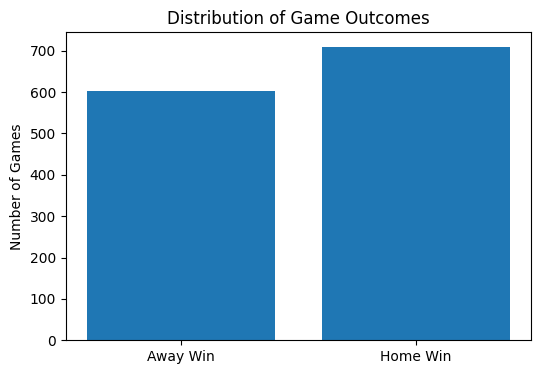

In [133]:
# class balance
counts = df_model["home_win"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Away Win", "Home Win"], [counts.get(0, 0), counts.get(1, 0)])
plt.title("Distribution of Game Outcomes")
plt.ylabel("Number of Games")
plt.show()

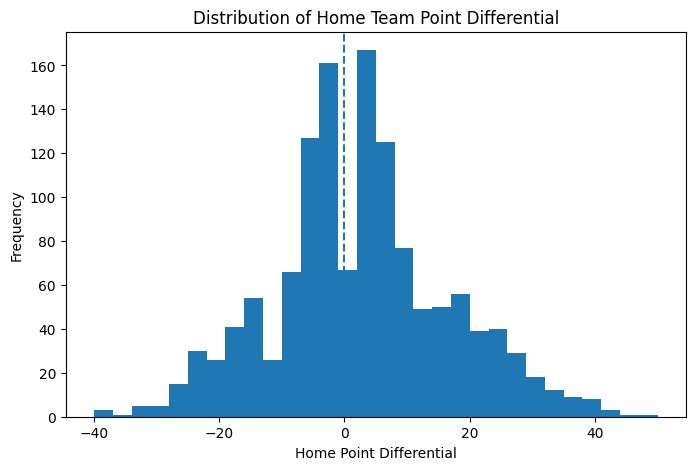

In [135]:
# histogram of home point differential 
plt.figure(figsize=(8, 5))
plt.hist(df_model["home_point_diff"], bins=30)
plt.title("Distribution of Home Team Point Differential")
plt.xlabel("Home Point Differential")
plt.ylabel("Frequency")
plt.axvline(0, linestyle="--")
plt.show()

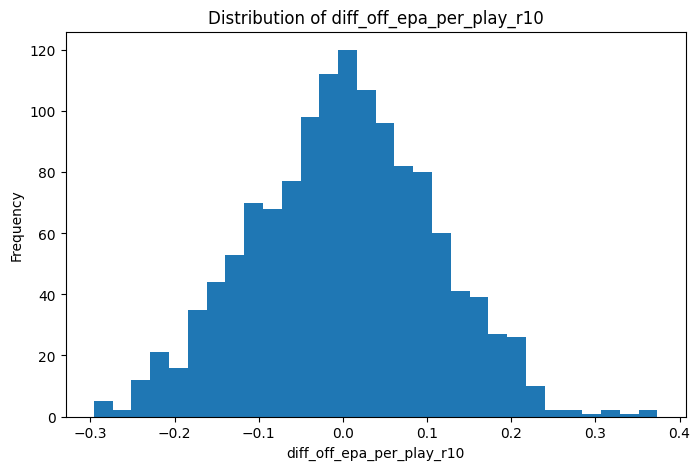

In [136]:
# feature distribution
plt.figure(figsize=(8, 5))
plt.hist(df_model["diff_off_epa_per_play_r10"].dropna(), bins=30)
plt.title("Distribution of diff_off_epa_per_play_r10")
plt.xlabel("diff_off_epa_per_play_r10")
plt.ylabel("Frequency")
plt.show()

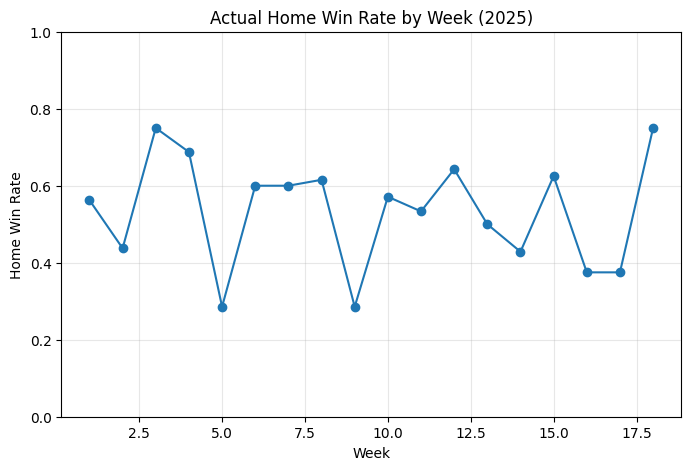

In [139]:
# weekly home win rate
weekly = df_model[df_model["season"] == 2025].groupby("week", as_index=False)["home_win"].mean()

plt.figure(figsize=(8, 5))
plt.plot(weekly["week"], weekly["home_win"], marker="o")
plt.title("Actual Home Win Rate by Week (2025)")
plt.xlabel("Week")
plt.ylabel("Home Win Rate")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

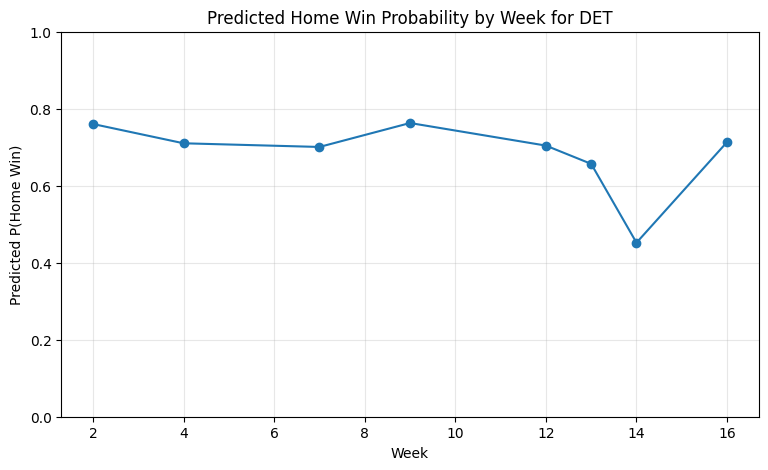

In [140]:
# team prediction trend
test_plot = test.copy()
test_plot["pred_home_win_prob"] = rf_proba

det_home = test_plot[test_plot["home_team"] == "DET"].sort_values("week")

plt.figure(figsize=(9, 5))
plt.plot(det_home["week"], det_home["pred_home_win_prob"], marker="o")
plt.title("Predicted Home Win Probability by Week for DET")
plt.xlabel("Week")
plt.ylabel("Predicted P(Home Win)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

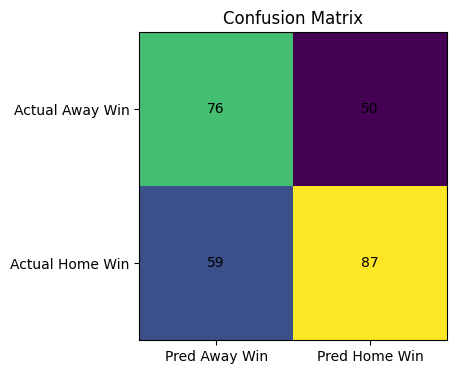

In [141]:
# confusion matrix
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred Away Win", "Pred Home Win"])
ax.set_yticklabels(["Actual Away Win", "Actual Home Win"])
ax.set_title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

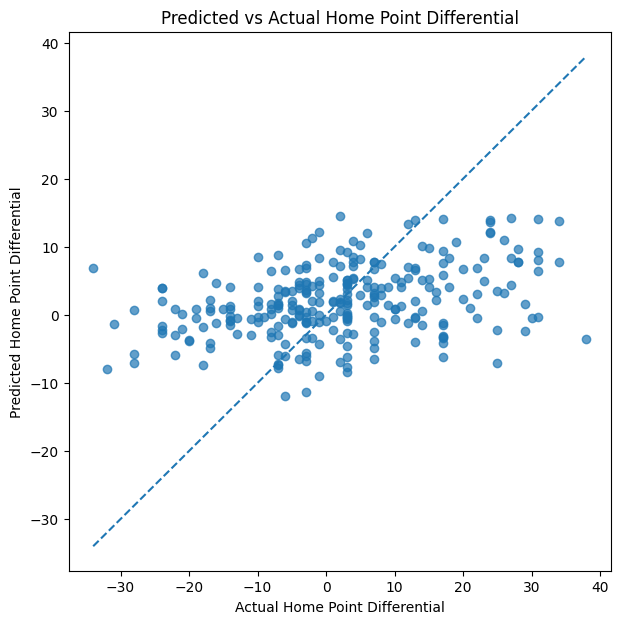

In [143]:
# predicted vs actual point differential
test_reg_plot = test.copy()
test_reg_plot["pred_home_point_diff"] = pred_point_diff

plt.figure(figsize=(7, 7))
plt.scatter(test_reg_plot["home_point_diff"], test_reg_plot["pred_home_point_diff"], alpha=0.7)

min_val = min(test_reg_plot["home_point_diff"].min(), test_reg_plot["pred_home_point_diff"].min())
max_val = max(test_reg_plot["home_point_diff"].max(), test_reg_plot["pred_home_point_diff"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Predicted vs Actual Home Point Differential")
plt.xlabel("Actual Home Point Differential")
plt.ylabel("Predicted Home Point Differential")
plt.show()

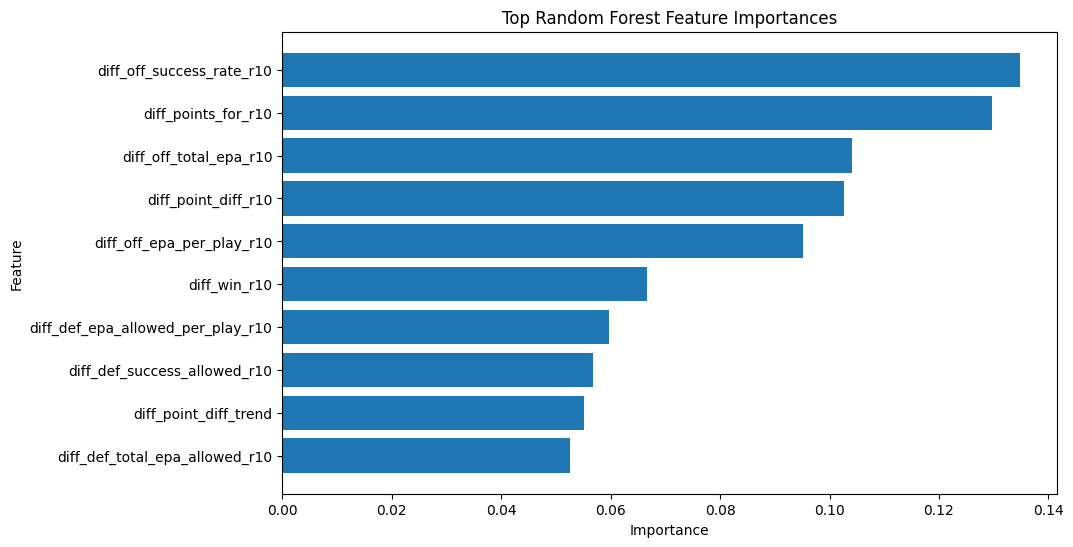

In [144]:
# random forest feature importance 
rf_model = rf.named_steps["model"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(importances.index[::-1], importances.values[::-1])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [145]:
results_table = test.copy()

results_table["pred_home_win"] = rf_pred
results_table["pred_home_win_prob"] = rf_proba

results_table["correct"] = (
    results_table["pred_home_win"] == results_table["home_win"]
).astype(int)

results_table = results_table[[
    "season", "week", "home_team", "away_team",
    "home_score", "away_score",
    "pred_home_win", "home_win",
    "pred_home_win_prob", "correct"
]]

results_table.head(10)

,season,week,home_team,away_team,home_score,away_score,pred_home_win,home_win,pred_home_win_prob,correct
1087,2025,1,PHI,DAL,24,20,1,1,0.795577,1
1088,2025,1,LAC,KC,27,21,1,1,0.701051,1
1089,2025,1,ATL,TB,20,23,0,0,0.380729,1
1090,2025,1,CLE,CIN,16,17,0,0,0.438547,1
1091,2025,1,IND,MIA,33,8,0,1,0.392703,0
1092,2025,1,JAX,CAR,26,10,0,1,0.381532,0
1093,2025,1,NE,LV,13,20,1,0,0.574267,0
1094,2025,1,NO,ARI,13,20,0,0,0.305481,1
1095,2025,1,NYJ,PIT,32,34,1,0,0.538139,0
1096,2025,1,WAS,NYG,21,6,1,1,0.836985,1


In [148]:
!pip install great_tables

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 9.1 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [184]:
# lions games table
test_with_preds = test.copy()

test_with_preds["pred_home_win"] = rf_pred
test_with_preds["pred_home_win_prob"] = rf_proba

test_with_preds["correct"] = (
    test_with_preds["pred_home_win"] == test_with_preds["home_win"]
).astype(int)

test_with_preds["pred_point_diff"] = pred_point_diff

lions = test_with_preds[
    (test_with_preds["home_team"] == "DET") | (test_with_preds["away_team"] == "DET")
].copy()

lions = lions.sort_values("week")
lions = lions.reset_index(drop=True)

lions["det_win_prob"] = np.where(
    lions["home_team"] == "DET",
    lions["pred_home_win_prob"],
    1 - lions["pred_home_win_prob"]
)

lions["det_point_diff_pred"] = np.where(
    lions["home_team"] == "DET",
    lions["pred_point_diff"],          # DET is home
    -lions["pred_point_diff"]          # DET is away → flip sign
)

lions["det_point_diff_actual"] = np.where(
    lions["home_team"] == "DET",
    lions["home_point_diff"],
    -lions["home_point_diff"]
)

lions["matchup"] = lions["away_team"] + " @ " + lions["home_team"]

lions["score"] = (
    lions["away_score"].astype(str) + " - " + lions["home_score"].astype(str)
)

# Convert prediction into team name
lions["predicted_winner"] = np.where(
    lions["pred_home_win"] == 1,
    lions["home_team"],
    lions["away_team"]
)

# Convert actual winner
lions["actual_winner"] = np.where(
    lions["home_win"] == 1,
    lions["home_team"],
    lions["away_team"]
)

# Nice label for correctness
lions["result"] = np.where(lions["correct"] == 1, "✅", "❌")

# logo columns
lions["lions_logo"] = "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/det.png"

team_logo_map = {
    "ARI": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/ari.png",
    "ATL": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/atl.png",
    "BAL": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/bal.png",
    "BUF": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/buf.png",
    "CAR": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/car.png",
    "CHI": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/chi.png",
    "CIN": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/cin.png",
    "CLE": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/cle.png",
    "DAL": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/dal.png",
    "DEN": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/den.png",
    "DET": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/det.png",
    "GB": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/gb.png",
    "HOU": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/hou.png",
    "IND": "hhttps://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/ind.png",
    "JAX": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/jax.png",
    "KC": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/kc.png",
    "LV": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/lv.png",
    "LAC": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/lac.png",
    "LA": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/lar.png",
    "MIA": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/mia.png",
    "MIN": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/min.png",
    "NE": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/ne.png",
    "NO": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/no.png",
    "NYG": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/nyg.png",
    "NYJ": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/nyj.png",
    "PHI": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/phi.png",
    "PIT": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/pit.png",
    "SEA": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/sea.png",
    "SF": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/sf.png",
    "TB": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/tb.png",
    "TEN": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/ten.png",
    "WAS": "https://a.espncdn.com/combiner/i?img=/i/teamlogos/nfl/500/was.png",
}

lions["opponent_team"] = np.where(
    lions["home_team"] == "DET",
    lions["away_team"],
    lions["home_team"]
)

lions["opp_logo"] = lions["opponent_team"].map(team_logo_map)

tbl = lions[[
    "week",
    "lions_logo",
    "opp_logo",
    "matchup",
    "score",
    "predicted_winner",
    "actual_winner",
    "det_point_diff_pred",
    "det_point_diff_actual",
    "det_win_prob",
    "result"
]].copy()

from great_tables import GT

gt = (
    GT(tbl)
    .tab_header(
        title="Detroit Lions Game Predictions",
        subtitle="Including Predicted vs Actual Point Differential"
    )
    .fmt_image(columns=["lions_logo", "opp_logo"], height=28)
    .cols_label(
    week="Week",
    lions_logo="DET",
    opp_logo="Opp",
    matchup="Matchup",
    score="Final Score",
    predicted_winner="Predicted",
    actual_winner="Actual",
    det_point_diff_pred="Pred Diff (DET)",
    det_point_diff_actual="Actual Diff (DET)",
    det_win_prob="Win Prob (DET)",
    result="Correct?"
)
    .cols_align(align="center")
    .cols_hide(columns='matchup')
    
    # ✅ FIXED COLORS
    .data_color(
        columns=["det_point_diff_pred", "det_point_diff_actual"],
        palette=["#d73027", "#f7f7f7", "#1a9850"]
    )
    .data_color(
        columns="det_win_prob",
        palette=["#deebf7", "#3182bd"]
    )

    .fmt_number(
        columns=["det_win_prob", "det_point_diff_pred", "det_point_diff_actual"],
        decimals=2
    )
)

In [185]:
gt

GT(_tbl_data=    week                                         lions_logo  \
0      1  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
1      2  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
2      3  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
3      4  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
4      5  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
5      6  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
6      7  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
7      9  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
8     10  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
9     11  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
10    12  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
11    13  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
12    14  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
13    15  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
14    16  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
15    17  https://a.espncdn.com/combiner/i?img=/i/teamlo...   
16    18  https://a.espncdn.com/combiner/i?img=/i/teamlo...   

                                             opp_logo    matchup    score  \
0   https://a.espncdn.com/combiner/i?img=/i/teamlo...   DET @ GB  13 - 27   
1   https://a.espncdn.com/combiner/i?img=/i/teamlo...  CHI @ DET  21 - 52   
2   https://a.espncdn.com/combiner/i?img=/i/teamlo...  DET @ BAL  38 - 30   
3   https://a.espncdn.com/combiner/i?img=/i/teamlo...  CLE @ DET  10 - 34   
4   https://a.espncdn.com/combiner/i?img=/i/teamlo...  DET @ CIN  37 - 24   
5   https://a.espncdn.com/combiner/i?img=/i/teamlo...   DET @ KC  17 - 30   
6   https://a.espncdn.com/combiner/i?img=/i/teamlo...   TB @ DET   9 - 24   
7   https://a.espncdn.com/combiner/i?img=/i/teamlo...  MIN @ DET  27 - 24   
8   https://a.espncdn.com/combiner/i?img=/i/teamlo...  DET @ WAS  44 - 22   
9   https://a.espncdn.com/combiner/i?img=/i/teamlo...  DET @ PHI   9 - 16   
10  https://a.espncdn.com/combiner/i?img=/i/teamlo...  NYG @ DET  27 - 34   
11  https://a.espncdn.com/combiner/i?img=/i/teamlo...   GB @ DET  31 - 24   
12  https://a.espncdn.com/combiner/i?img=/i/teamlo...  DAL @ DET  30 - 44   
13  https://a.espncdn.com/combiner/i?img=/i/teamlo...   DET @ LA  34 - 41   
14  https://a.espncdn.com/combiner/i?img=/i/teamlo...  PIT @ DET  29 - 24   
15  https://a.espncdn.com/combiner/i?img=/i/teamlo...  DET @ MIN  10 - 23   
16  https://a.espncdn.com/combiner/i?img=/i/teamlo...  DET @ CHI  19 - 16   

   predicted_winner actual_winner  det_point_diff_pred  det_point_diff_actual  \
0               DET            GB             1.515199                    -14   
1               DET           DET            14.084328                     31   
2               DET           DET            -0.150582                      8   
3               DET           DET            12.140576                     24   
4               DET           DET             2.835088                     13   
5               DET            KC             4.037408                    -13   
6               DET           DET             5.258668                     15   
7               DET           MIN            10.515177                     -3   
8               DET           DET             2.960564                     22   
9               DET           PHI             3.916681                     -7   
10              DET           DET             6.765546                      7   
11              DET            GB             3.740995                     -7   
12              DAL           DET             0.633235                     14   
13               LA            LA            -7.779542                     -7   
14              DET           PIT             1.969639                     -5   
15              DET           MIN            -2.039363                    -13   
16              CHI           DET            -4.850089                      3   

    de

In [189]:
# LR vs RF
lr_acc = accuracy_score(y_test, log_pred)
lr_auc = roc_auc_score(y_test, log_proba)

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

import pandas as pd

model_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc],
    "ROC_AUC": [lr_auc, rf_auc]
})


from great_tables import GT

gt_models = (
    GT(model_df)
    .tab_header(
        title="Model Comparison",
        subtitle="Logistic Regression vs Random Forest"
    )
    .cols_label(
        Model="Model",
        Accuracy="Accuracy",
        ROC_AUC="ROC-AUC"
    )
    .fmt_number(
        columns=["Accuracy", "ROC_AUC"],
        decimals=3
    )
    .cols_align(align="center")
)
gt_models

GT(_tbl_data=                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.621324  0.664873
1        Random Forest  0.599265  0.633072, _body=<great_tables._gt_data.Body object at 0xffff5c6f96f0>, _boxhead=Boxhead([ColInfo(var='Model', type=<ColInfoTypeEnum.default: 1>, column_label='Model', column_align='center', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='center', column_width=None), ColInfo(var='ROC_AUC', type=<ColInfoTypeEnum.default: 1>, column_label='ROC-AUC', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0xffff5c6fa110>, _spanners=Spanners([]), _heading=Heading(title='Model Comparison', subtitle='Logistic Regression vs Random Forest', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0xffff5c6f84f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0xffff5c6fb9a0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0xffff5c6fb820>, _formats=[<great_tables._gt_data.FormatInfo object at 0xffff5c6f9480>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading